# Guia practica para reproducir el analisis de CO2 (Mauna Loa NOAA)

Este notebook sirve como plantilla para:
- cargar series diarias, semanales y mensuales de NOAA,
- limpiar faltantes,
- visualizar diferencias por escala temporal,
- calcular agregaciones, anomalias y tendencias,
- preparar una interpretacion para modelacion ambiental y politica climatica.

## 1) Preparacion del entorno
Si falta alguna libreria, ejecuta la celda de instalacion una sola vez.

In [1]:
# Descomenta esta linea si necesitas instalar paquetes en el entorno actual.
# %pip install pandas numpy matplotlib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## 2) Descarga y rutas de archivos
Descarga los archivos de NOAA desde:
https://gml.noaa.gov/ccgg/trends/data.html

Usa los archivos de Mauna Loa (daily, weekly, monthly) y ajusta las rutas.

In [3]:
from pathlib import Path

REPO_ROOT = Path.cwd()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks' if (REPO_ROOT / 'notebooks').exists() else REPO_ROOT

path_daily = NOTEBOOK_DIR / 'co2_daily_mlo.csv'
path_weekly = NOTEBOOK_DIR / 'co2_weekly_mlo.csv'
path_monthly = NOTEBOOK_DIR / 'co2_mm_mlo.csv'
path_annual = NOTEBOOK_DIR / 'co2_annmean_mlo.csv'

for path in [path_daily, path_weekly, path_monthly, path_annual]:
    if not path.exists():
        raise FileNotFoundError(f'No se encontro el archivo requerido: {path}')

print('Usando archivos NOAA desde:', NOTEBOOK_DIR)


Usando archivos NOAA desde: /home/gentek-g3-esp/jupyterbook_Modelacion_Ambiental/notebooks


## 3) Funcion robusta de lectura NOAA
- Ignora comentarios con `comment='#'`.
- Usa separacion por espacios.
- Convierte columnas a numerico.
- Reemplaza `-999.99` por `NaN`.
- Construye columna `date` con year, month y day.

In [4]:
def read_noaa_co2(path):
    # 1) Intento principal: formato CSV (separado por comas)
    df = pd.read_csv(path, comment='#', header=None)

    # 2) Si quedo en una sola columna, probablemente es TXT con espacios
    if df.shape[1] == 1:
        df = pd.read_csv(path, comment='#', sep=r'\s+', header=None, engine='python')

    # Convertir todo a numerico para limpiar filas no numericas
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all').reset_index(drop=True)

    ncol = df.shape[1]
    if ncol < 5:
        raise ValueError(f'Formato inesperado en {path}. Columnas detectadas: {ncol}')

    # Determinar esquema: mensual (col 3 es decimal_date) vs diario/semanal (col 3 es day)
    third_col_median = df.iloc[:, 2].median(skipna=True)

    if third_col_median is not None and third_col_median > 31:
        # Esquema mensual: year, month, decimal_date, average, ...
        out = pd.DataFrame({
            'year': df.iloc[:, 0],
            'month': df.iloc[:, 1],
            'day': 1,
            'decimal_date': df.iloc[:, 2],
            'average': df.iloc[:, 3],
        })
    else:
        # Esquema diario/semanal: year, month, day, decimal_date, average, ...
        out = pd.DataFrame({
            'year': df.iloc[:, 0],
            'month': df.iloc[:, 1],
            'day': df.iloc[:, 2],
            'decimal_date': df.iloc[:, 3],
            'average': df.iloc[:, 4],
        })

    # Faltantes NOAA frecuentes
    out['average'] = out['average'].replace([-999.99, -99.99, -9.99], np.nan)

    # Tipos y fecha
    out['year'] = pd.to_numeric(out['year'], errors='coerce').astype('Int64')
    out['month'] = pd.to_numeric(out['month'], errors='coerce').astype('Int64')
    out['day'] = pd.to_numeric(out['day'], errors='coerce').astype('Int64')
    out['decimal_date'] = pd.to_numeric(out['decimal_date'], errors='coerce')

    out['date'] = pd.to_datetime(
        dict(year=out['year'], month=out['month'], day=out['day']),
        errors='coerce'
    )

    # Filtrar filas utiles
    out = out.dropna(subset=['date', 'average', 'decimal_date']).copy()
    return out


def read_noaa_annual(path):
    # Formato esperado: year, annual_mean, uncertainty
    df = pd.read_csv(path, comment='#', header=None)
    if df.shape[1] == 1:
        df = pd.read_csv(path, comment='#', sep=r'\s+', header=None, engine='python')

    df = df.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)
    if df.shape[1] < 2:
        raise ValueError(f'Formato inesperado en {path}.')

    out = pd.DataFrame({
        'year': pd.to_numeric(df.iloc[:, 0], errors='coerce').astype('Int64'),
        'average': pd.to_numeric(df.iloc[:, 1], errors='coerce'),
    })
    out['average'] = out['average'].replace([-999.99, -99.99, -9.99], np.nan)
    out['date'] = pd.to_datetime(dict(year=out['year'], month=1, day=1), errors='coerce')
    out['decimal_date'] = out['year'].astype(float)
    out = out.dropna(subset=['year', 'date', 'average'])
    return out


## 4) Carga de datos

In [5]:
df_daily = read_noaa_co2(path_daily)
df_weekly = read_noaa_co2(path_weekly)
df_monthly = read_noaa_co2(path_monthly)
df_annual = read_noaa_annual(path_annual)

# Series derivadas desde daily (para comparaciones metodologicas en periodo comun)
daily_series = df_daily.set_index('date')['average'].sort_index()
weekly_from_daily = daily_series.resample('W').mean().dropna()
monthly_from_daily = daily_series.resample('MS').mean().dropna()

print('daily  :', df_daily.shape)
print('weekly :', df_weekly.shape)
print('monthly:', df_monthly.shape)
print('annual :', df_annual.shape)
print('weekly_from_daily :', weekly_from_daily.shape)
print('monthly_from_daily:', monthly_from_daily.shape)

print('\nPrimeras filas (monthly):')
display(df_monthly.head())


daily  : (15838, 6)
weekly : (2681, 6)
monthly: (815, 6)
annual : (67, 4)
weekly_from_daily : (2682,)
monthly_from_daily: (621,)

Primeras filas (monthly):


,year,month,day,decimal_date,average,date
0,1958,3,1,1958.2027,315.71,1958-03-01
1,1958,4,1,1958.2877,317.45,1958-04-01
2,1958,5,1,1958.3699,317.51,1958-05-01
3,1958,6,1,1958.4548,317.27,1958-06-01
4,1958,7,1,1958.5370,315.87,1958-07-01


## 5) Exploracion y visualizacion por escala

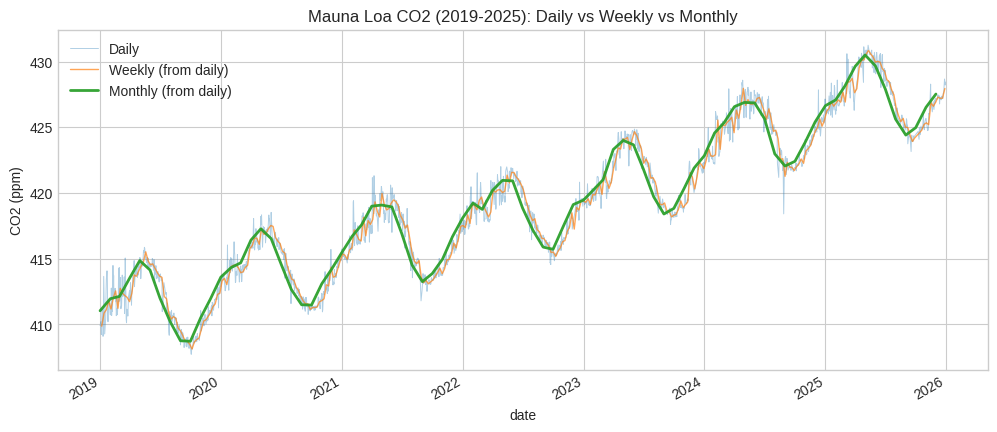

In [6]:
# Comparacion enfocada en 2019-2025
# Se usan weekly/monthly derivados desde daily para mantener consistencia metodologica.
daily_2019_2025 = daily_series.loc['2019-01-01':'2025-12-31']
weekly_2019_2025 = weekly_from_daily.loc['2019-01-01':'2025-12-31']
monthly_2019_2025 = monthly_from_daily.loc['2019-01-01':'2025-12-31']

fig, ax = plt.subplots(figsize=(12, 5))

daily_2019_2025.plot(ax=ax, lw=0.7, alpha=0.35, label='Daily')
weekly_2019_2025.plot(ax=ax, lw=1.0, alpha=0.70, label='Weekly (from daily)')
monthly_2019_2025.plot(ax=ax, lw=2.0, alpha=0.95, label='Monthly (from daily)')

ax.set_ylabel('CO2 (ppm)')
ax.set_title('Mauna Loa CO2 (2019-2025): Daily vs Weekly vs Monthly')
ax.legend()
plt.show()


### Interpretacion - Figura 1 (daily, weekly, monthly; 2019-2025)

La serie diaria presenta mayor dispersion por variabilidad de alta frecuencia (meteorologia local, condiciones de muestreo y variabilidad diurna).
Al promediar semanalmente, la varianza se reduce y se conserva la senal submensual.
La agregacion mensual filtra gran parte del ruido de alta frecuencia y permite identificar el ciclo estacional anual con mayor claridad.


In [7]:
std_daily = daily_2019_2025.std()
std_weekly = weekly_2019_2025.std()
std_monthly = monthly_2019_2025.std()

print("=== Conclusiones Figura 1 ===")
print("Desviacion estandar total 2019-2025 (incluye ciclo estacional):")
print(f"  Daily   : {std_daily:.3f} ppm")
print(f"  Weekly  : {std_weekly:.3f} ppm")
print(f"  Monthly : {std_monthly:.3f} ppm")
print("Numero de datos en el periodo:")
print(f"  Daily   : {len(daily_2019_2025)}")
print(f"  Weekly  : {len(weekly_2019_2025)}")
print(f"  Monthly : {len(monthly_2019_2025)}")
print("Interpretacion: la reduccion de ruido se observa en la figura al pasar de daily a weekly y monthly,")
print("mientras la desviacion total se mantiene similar porque las tres series retienen el ciclo estacional anual.")


=== Conclusiones Figura 1 ===
Desviacion estandar total 2019-2025 (incluye ciclo estacional):
  Daily   : 5.540 ppm
  Weekly  : 5.537 ppm
  Monthly : 5.546 ppm
Numero de datos en el periodo:
  Daily   : 2202
  Weekly  : 364
  Monthly : 84
Interpretacion: la reduccion de ruido se observa en la figura al pasar de daily a weekly y monthly,
mientras la desviacion total se mantiene similar porque las tres series retienen el ciclo estacional anual.


## 6) Media movil de 6 meses en la serie mensual

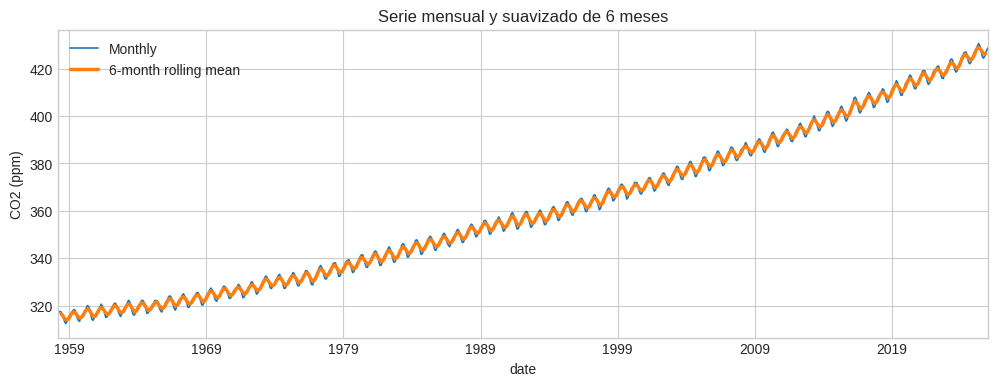

In [8]:
m = df_monthly.set_index('date')['average'].sort_index()
m_6m = m.rolling(window=6, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
m.plot(ax=ax, lw=1.2, label='Monthly')
m_6m.plot(ax=ax, lw=2.5, label='6-month rolling mean')

ax.set_ylabel('CO2 (ppm)')
ax.set_title('Serie mensual y suavizado de 6 meses')
ax.legend()
plt.show()

### Interpretacion - Figura 2 (mensual + media movil 6 meses)

La media movil de 6 meses conserva la estructura estacional principal y enfatiza la tendencia de fondo.
La senal muestra un incremento sostenido desde finales de los anos 50 hasta el presente, consistente con el aumento antropogenico de CO2 atmosferico.


In [9]:
m_1958 = m.loc['1958-03-01':'1958-12-31']
m_2025 = m.loc['2025-01-01':'2025-12-31']

slope_monthly_full = np.polyfit(df_monthly['decimal_date'], df_monthly['average'], 1)[0]
slope_daily_full = np.polyfit(df_daily['decimal_date'], df_daily['average'], 1)[0]
slope_weekly_full = np.polyfit(df_weekly['decimal_date'], df_weekly['average'], 1)[0]

print("=== Conclusiones Figura 2 ===")
print(f"Nivel inicial (1958, primer mes): {m_1958.iloc[0]:.2f} ppm")
print(f"Rango 2025 (min-max): {m_2025.min():.2f} - {m_2025.max():.2f} ppm")
print(f"Pendiente mensual completa : {slope_monthly_full:.3f} ppm/anio")
print(f"Pendiente diaria completa  : {slope_daily_full:.3f} ppm/anio")
print(f"Pendiente semanal completa : {slope_weekly_full:.3f} ppm/anio")


=== Conclusiones Figura 2 ===
Nivel inicial (1958, primer mes): 315.71 ppm
Rango 2025 (min-max): 424.37 - 430.51 ppm
Pendiente mensual completa : 1.661 ppm/anio
Pendiente diaria completa  : 1.879 ppm/anio
Pendiente semanal completa : 1.873 ppm/anio


## 7) Agregaciones adicionales (trimestral y anual)

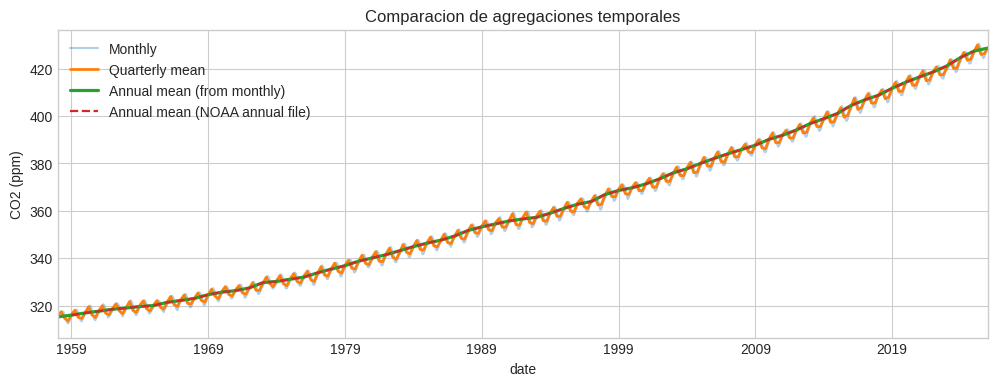

In [10]:
# En pandas modernos se recomienda QE y YE.
q_mean = m.resample('QE').mean()
y_mean_from_monthly = m.resample('YE').mean()

# Media anual directa NOAA (archivo anual)
y_mean_noaa = df_annual.set_index('date')['average'].sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
m.plot(ax=ax, alpha=0.35, label='Monthly')
q_mean.plot(ax=ax, lw=2.0, label='Quarterly mean')
y_mean_from_monthly.plot(ax=ax, lw=2.3, label='Annual mean (from monthly)')
y_mean_noaa.plot(ax=ax, lw=1.6, ls='--', label='Annual mean (NOAA annual file)')

ax.set_ylabel('CO2 (ppm)')
ax.set_title('Comparacion de agregaciones temporales')
ax.legend()
plt.show()


### Interpretacion - Figura 4 (trimestral vs anual)

El promedio anual elimina la estacionalidad y resalta la tendencia secular.
El promedio trimestral conserva parte del ciclo anual y permite equilibrar reduccion de ruido y resolucion temporal.
Esta diferencia de escalas es clave para elegir indicadores segun el objetivo (seguimiento de tendencia de fondo vs variabilidad intraanual).


In [11]:
# Alinear por anio para evitar diferencias de fecha (YE: fin de anio vs annual NOAA: inicio de anio)
ann_from_monthly = y_mean_from_monthly.copy()
ann_from_monthly.index = ann_from_monthly.index.year
ann_noaa = y_mean_noaa.copy()
ann_noaa.index = ann_noaa.index.year

common_years = ann_from_monthly.index.intersection(ann_noaa.index)
diff = (ann_from_monthly.loc[common_years] - ann_noaa.loc[common_years]).dropna()

print("=== Conclusiones Figura 4 ===")
print("Comparacion anual (from monthly vs NOAA annual):")
print(f"  N comun: {len(diff)}")
print(f"  Diferencia media: {diff.mean():.4f} ppm")
print(f"  Desv. estandar : {diff.std():.4f} ppm")
print("Interpretacion: ambas series anuales son altamente consistentes.")


=== Conclusiones Figura 4 ===
Comparacion anual (from monthly vs NOAA annual):
  N comun: 67
  Diferencia media: 0.0004 ppm
  Desv. estandar : 0.0030 ppm
Interpretacion: ambas series anuales son altamente consistentes.


## 8) Amplitud anual del ciclo estacional

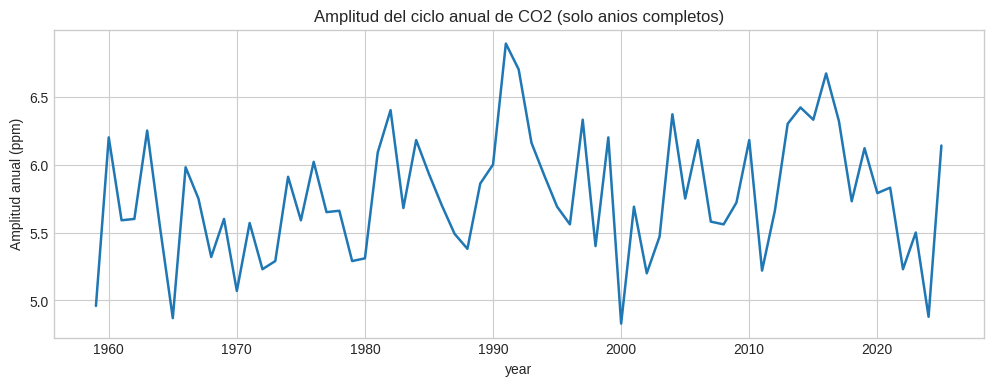

Amplitud media por decada (ppm):
year
1950    4.960000
1960    5.670000
1970    5.528000
1980    5.802000
1990    6.085000
2000    5.635000
2010    6.095000
2020    5.561667
Name: average, dtype: float64

1960s: 5.669999999999993
2014-2023: 5.993999999999988


In [12]:
dfm = df_monthly.copy()
dfm['year'] = dfm['date'].dt.year

# Excluir anios incompletos (menos de 12 meses)
months_per_year = dfm.groupby('year')['average'].count()
full_years = months_per_year[months_per_year == 12].index
dfm_full = dfm[dfm['year'].isin(full_years)].copy()

annual_amp = dfm_full.groupby('year')['average'].agg(lambda x: x.max() - x.min())

fig, ax = plt.subplots(figsize=(12, 4))
annual_amp.plot(ax=ax, lw=1.8)

ax.set_ylabel('Amplitud anual (ppm)')
ax.set_title('Amplitud del ciclo anual de CO2 (solo anios completos)')
plt.show()

# Resumen por decadas y comparacion pedida
decadal_amp = annual_amp.groupby((annual_amp.index // 10) * 10).mean()
print('Amplitud media por decada (ppm):')
print(decadal_amp)
print('\n1960s:', float(decadal_amp.loc[1960]))
print('2014-2023:', float(annual_amp.loc[2014:2023].mean()))


### Interpretacion - Figura 3 (amplitud anual)

La amplitud anual (maximo - minimo mensual) resume la intensidad del ciclo estacional.
A escala de decadas, se observa un aumento leve respecto a los anos 60.
En anos recientes aparecen valores bajos (2022-2024), coherentes con el periodo de interrupcion y relocalizacion temporal de mediciones en Mauna Loa.


In [13]:
print("=== Conclusiones Figura 3 ===")
print(f"Amplitud media anos 60 (1960s): {float(decadal_amp.loc[1960]):.3f} ppm")
print(f"Amplitud media 2014-2023      : {float(annual_amp.loc[2014:2023].mean()):.3f} ppm")
print("Amplitudes recientes:")
for y in [2021, 2022, 2023, 2024, 2025]:
    if y in annual_amp.index:
        print(f"  {y}: {annual_amp.loc[y]:.2f} ppm")


=== Conclusiones Figura 3 ===
Amplitud media anos 60 (1960s): 5.670 ppm
Amplitud media 2014-2023      : 5.994 ppm
Amplitudes recientes:
  2021: 5.83 ppm
  2022: 5.23 ppm
  2023: 5.50 ppm
  2024: 4.88 ppm
  2025: 6.14 ppm


## 9) Anomalias respecto a un periodo de referencia

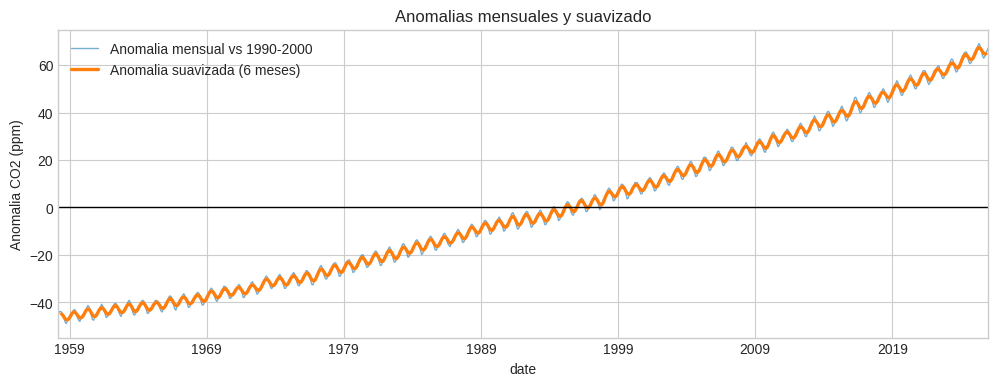

In [14]:
ref_start, ref_end = '1990-01-01', '2000-12-31'
ref_mean = m.loc[ref_start:ref_end].mean()
anom = m - ref_mean
anom_6m = anom.rolling(window=6, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
anom.plot(ax=ax, lw=1.0, alpha=0.6, label=f'Anomalia mensual vs {ref_start[:4]}-{ref_end[:4]}')
anom_6m.plot(ax=ax, lw=2.4, label='Anomalia suavizada (6 meses)')
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('Anomalia CO2 (ppm)')
ax.set_title('Anomalias mensuales y suavizado')
ax.legend()
plt.show()


### Interpretacion - Figura 5 (anomalias 1990-2000)

Las anomalias positivas crecientes indican que el sistema se desplaza persistentemente por encima del nivel de referencia 1990-2000.
El suavizado de 6 meses reduce oscilaciones de corto plazo y permite ver con mas claridad el incremento de fondo y su aceleracion en decadas recientes.


In [15]:
# Pendientes de anomalia para evidenciar aceleracion
tmp = df_monthly.copy()
tmp['anom'] = tmp['average'] - ref_mean

p1 = tmp[(tmp['date'] >= '1958-01-01') & (tmp['date'] <= '1999-12-31')]
p2 = tmp[(tmp['date'] >= '2000-01-01') & (tmp['date'] <= '2025-12-31')]

s1 = np.polyfit(p1['decimal_date'], p1['anom'], 1)[0]
s2 = np.polyfit(p2['decimal_date'], p2['anom'], 1)[0]

print("=== Conclusiones Figura 5 ===")
print(f"Media referencia 1990-2000: {ref_mean:.3f} ppm")
print(f"Anomalia ultimo dato mensual: {(m.iloc[-1] - ref_mean):.3f} ppm")
print(f"Pendiente anomalia 1958-1999: {s1:.3f} ppm/anio")
print(f"Pendiente anomalia 2000-2025: {s2:.3f} ppm/anio")
print("Interpretacion: la tasa reciente es mayor, consistente con aceleracion.")


=== Conclusiones Figura 5 ===
Media referencia 1990-2000: 361.414 ppm
Anomalia ultimo dato mensual: 67.206 ppm
Pendiente anomalia 1958-1999: 1.323 ppm/anio
Pendiente anomalia 2000-2025: 2.279 ppm/anio
Interpretacion: la tasa reciente es mayor, consistente con aceleracion.


## 10) Tendencia lineal y tasa de crecimiento

In [16]:
def slope_ppm_per_year(df):
    x = df['decimal_date'].values
    y = df['average'].values
    mask = np.isfinite(x) & np.isfinite(y)
    b1, b0 = np.polyfit(x[mask], y[mask], 1)  # y = b1*x + b0
    return b1

# Pendiente en todo el periodo disponible de cada serie
slope_full = {
    'daily': slope_ppm_per_year(df_daily),
    'weekly': slope_ppm_per_year(df_weekly),
    'monthly': slope_ppm_per_year(df_monthly),
    'annual_noaa': slope_ppm_per_year(df_annual),
}

# Para comparacion justa entre escalas, usar periodo comun
common_start = max(df_daily['date'].min(), df_weekly['date'].min(), df_monthly['date'].min())
common_end = min(df_daily['date'].max(), df_weekly['date'].max(), df_monthly['date'].max())

mask_daily = (df_daily['date'] >= common_start) & (df_daily['date'] <= common_end)
mask_weekly = (df_weekly['date'] >= common_start) & (df_weekly['date'] <= common_end)
mask_monthly = (df_monthly['date'] >= common_start) & (df_monthly['date'] <= common_end)

slope_overlap = {
    'daily': slope_ppm_per_year(df_daily.loc[mask_daily]),
    'weekly': slope_ppm_per_year(df_weekly.loc[mask_weekly]),
    'monthly': slope_ppm_per_year(df_monthly.loc[mask_monthly]),
}

summary = pd.DataFrame({
    'series': ['daily', 'weekly', 'monthly', 'annual_noaa'],
    'n_obs': [len(df_daily), len(df_weekly), len(df_monthly), len(df_annual)],
    'trend_full_period_ppm_per_year': [slope_full['daily'], slope_full['weekly'], slope_full['monthly'], slope_full['annual_noaa']],
    'trend_common_period_ppm_per_year': [slope_overlap['daily'], slope_overlap['weekly'], slope_overlap['monthly'], np.nan],
})

print(f'Periodo comun: {common_start.date()} a {common_end.date()}')
summary


Periodo comun: 1974-05-19 a 2026-01-01


,series,n_obs,trend_full_period_ppm_per_year,trend_common_period_ppm_per_year
0,daily,15838,1.879212,1.877489
1,weekly,2681,1.872809,1.870902
2,monthly,815,1.660642,1.871384
3,annual_noaa,67,1.671966,NaN


## 11) Guion de interpretacion (para tu reporte)

Puntos sugeridos:
1. Como cambia la señal al pasar de daily a weekly y monthly.
2. Que procesos emergen con agregacion (tendencia de fondo) y cuales se atenun (ruido corto).
3. Comparacion de pendientes entre escalas y estabilidad de la estimacion.
4. Evolucion de la amplitud anual y posible lectura biogeoquimica.
5. Relevancia para politica climatica: el IPCC usa periodos de 20 anos para niveles de calentamiento, por lo que escalas mensuales-anuales y promedios multianuales son mas utiles para decision.

## 12) Extensiones posibles

- Aplicar FFT para separar componentes de alta y baja frecuencia.
- Comparar Mauna Loa con otros observatorios NOAA o series globales.
- Relacionar anomalias de CO2 con ENSO (Nino) y eventos volcanicos.